In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *

In [3]:
# myPredictorsDf.treatment_hypothermia.sum()

In [4]:
columns= [
    'patientunitstayid','gender','age','bmi',
    'nurse_first_Non-Invasive BP Systolic',
    'nurse_first_Non-Invasive BP Diastolic',
    'nurse_first_Non-Invasive BP Mean',
    'nurse_first_Heart Rate',
    'nurse_first_O2 Saturation',
    'nurse_first_Temperature (C)',
    'lab_first_Respiratory Rate',
    'lab_first_FiO2',
    'nurse_first_GCS Total',
    'nurse_first_Motor','FirstGCS','LastGCS','LastGCS15',
    'nurse_first_QTc',
    'lab_first_pH','lab_first_paO2','lab_first_paCO2',
    'lab_first_bicarbonate','lab_first_lactate',
    'lab_first_WBC x 1000','lab_first_Hgb','lab_first_platelets x 1000',
    'lab_first_sodium','lab_first_potassium','lab_first_BUN',
    'lab_first_creatinine','lab_first_calcium','lab_first_magnesium',
    'lab_first_glucose','lab_first_troponin - I','lab_first_troponin - T',
    'diagnosis_initial rhythm: ventricular fibrillation',
    'diagnosis_ventricular fibrillation',
    'diagnosis_ventricular tachycardia',
    'diagnosis_initial rhythm: ventricular tachycardia',
    'diagnosis_initial rhythm: pulseless electrical activity',
    'diagnosis_initial rhythm: asystole',
    # 'FirstMGCS',
    # 'hypothermia_time',
]


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')
    myPredictorsDf['hypothermia_time'].fillna(0,inplace=True)
    print(myPredictorsDf.shape)
    # Preprocessing
    # print(myPredictorsDf['hypothermia_time'])
    myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
    myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime'])# & (myPredictorsDf['FirstMGCS'] != 1)
    myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
    myPredictorsDf.LastGCS15 = 0
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.nurse_first_Motor != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myFilter & myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['FirstGCS',
                                                         'LastMGCSTime', 
                                                         'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 
                                                         'apacheadmissiondx', 'hospitaladmittime24', 
                                                         'FirstGCSTime', 'LastGCSTime', 'LastGCS', 
                                                         'hospitaldischargestatus', 
                                                         'LastGCS15', 'hospitaladmitsource', 
                                                         'DeathAtDischarge', 'patientunitstayid', 'hypothermia_time'])
    # myXValue = myXValue[columns]
    myXValue = myXValue
    # myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
    # myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [24]:
# X_train_no_group

In [25]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myTreatment = 'Hypothermia'
myPredicted = 'DeathAtDischarge'
myPredictorsDf, X_train_no_group, X_test_no_group, T_train, T_test, y_train, y_test =  \
                    getTrainTestFunctions(aPredictedColumn = myPredicted, 
                                            aTreatmentColumn = myTreatment, aTreatmentSplit = True, aSkipTemp = True, 
                                            aDropColumns = 
                                            [], 
                                            aTestSize=.3)
columns_filter = np.unique([x for x in columns if x in X_train_no_group.columns])
X_train_no_group = X_train_no_group[columns_filter]
X_test_no_group = X_test_no_group[columns_filter]
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=3, n_estimators=50),  
    model_t= XGBClassifier(max_depth=2, n_estimators=20),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
    n_jobs=-1
)

/local/mbranda1/3100884/ipykernel_4170794/2316976194.py:6: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')
/local/mbranda1/3100884/ipykernel_4170794/2316976194.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myPredictorsDf['hypothermia_time'].fillna(0,inplace=True)


(3172, 2914)


In [8]:
X_train_no_group.columns

Index(['age', 'bmi', 'diagnosis_initial rhythm: asystole',
       'diagnosis_initial rhythm: pulseless electrical activity',
       'diagnosis_initial rhythm: ventricular fibrillation',
       'diagnosis_initial rhythm: ventricular tachycardia',
       'diagnosis_ventricular fibrillation',
       'diagnosis_ventricular tachycardia', 'gender', 'lab_first_BUN',
       'lab_first_FiO2', 'lab_first_Hgb', 'lab_first_Respiratory Rate',
       'lab_first_WBC x 1000', 'lab_first_bicarbonate', 'lab_first_calcium',
       'lab_first_creatinine', 'lab_first_glucose', 'lab_first_lactate',
       'lab_first_magnesium', 'lab_first_pH', 'lab_first_paCO2',
       'lab_first_paO2', 'lab_first_platelets x 1000', 'lab_first_potassium',
       'lab_first_sodium', 'lab_first_troponin - I', 'lab_first_troponin - T',
       'nurse_first_GCS Total', 'nurse_first_Heart Rate', 'nurse_first_Motor',
       'nurse_first_Non-Invasive BP Diastolic',
       'nurse_first_Non-Invasive BP Mean',
       'nurse_first_Non-

In [9]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]

In [10]:
# X_train_no_group = X_train_no_group.fillna(0)
# X_test_no_group = X_test_no_group.fillna(0)

In [11]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))

In [12]:
# myPipeline.fit_transform(X_train_no_group)

In [13]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [21]:
myNewXTest.shape[0] + myNewXTrain.shape[0]

1842

In [22]:
myPredictorsDf.shape

(1842, 1791)

In [14]:
causal_forest.fit(y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(y_train, T_train, X=myNewXTrain))

CATE_pred = causal_forest.effect(myNewXTrain)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend w

0.09019043285916817
Feature importances [0.02417767 0.04204451 0.03852926 0.02040268 0.03376464 0.03185446
 0.04354762 0.07577399 0.03237981 0.04363529 0.02366293 0.03396392
 0.0850535  0.02904763 0.02217917 0.03612369 0.02804594 0.05195471
 0.02477079 0.02883628 0.05502894 0.05771508 0.01500932 0.02694754
 0.02462112 0.03444301 0.01359951 0.00025922 0.00324973 0.00361442
 0.00020126 0.         0.         0.00538421 0.00632899 0.
 0.         0.0012243  0.00024599 0.00237884 0.         0.
 0.         0.        ]
Predicted CATE for test data: [[-0.05160039]
 [-0.14484046]
 [-0.05610979]
 [-0.07158075]
 [-0.01370032]
 [-0.16028288]
 [-0.19289963]
 [-0.04856641]
 [-0.0649046 ]
 [-0.05381403]]


[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


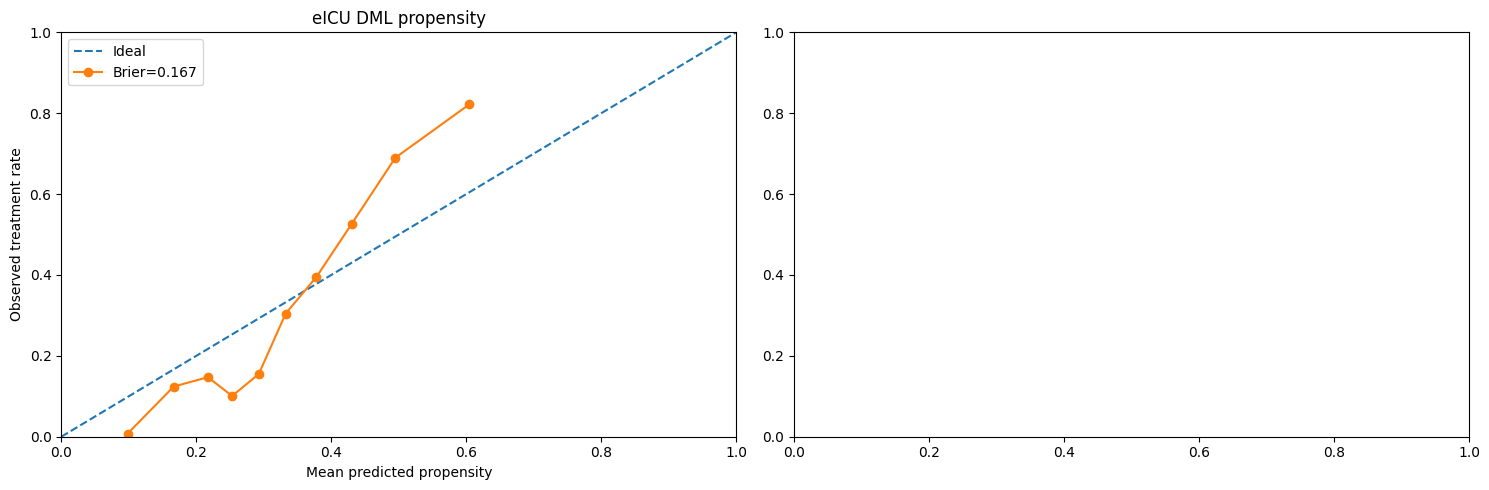

,dataset,n,treatment_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,1289,0.327,0.827,0.167,0.69,2.178


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
import statsmodels.api as sm
def _combine_x_w(X=None, W=None):
    if X is None and W is None:
        raise ValueError("At least one of X or W must be provided.")
    if X is None:
        return np.asarray(W)
    if W is None:
        return np.asarray(X)
    return np.hstack([np.asarray(X), np.asarray(W)])
def get_cf_propensity_scores(cf, X=None, W=None):
    """
    Average propensity predictions from fitted treatment nuisance models
    inside a fitted CausalForestDML object.
    """
    XW = _combine_x_w(X, W)
    preds = []

    for mc_models in cf.models_t:
        for mdl in mc_models:
            if hasattr(mdl, "predict_proba"):
                p = mdl.predict_proba(XW)
                if p.ndim == 2 and p.shape[1] == 2:
                    p = p[:, 1]
                else:
                    p = np.asarray(p).reshape(-1)
            elif hasattr(mdl, "predict"):
                p = mdl.predict(XW)
            else:
                raise ValueError(f"Model {type(mdl)} has neither predict_proba nor predict.")
            preds.append(np.asarray(p).reshape(-1))

    p_hat = np.mean(np.vstack(preds), axis=0)
    return np.clip(p_hat, 1e-6, 1 - 1e-6)
def calibration_intercept_slope_binary(y_true, y_prob, eps=1e-6):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob).astype(float), eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)
    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]
    return intercept, slope
def dml_propensity_calibration_plot(cf, T, X=None, W=None, title="", n_bins=10, ax=None):
    """
    Calibration plot for the treatment nuisance model inside CausalForestDML.
    """
    T = np.asarray(T).astype(int).ravel()
    p_hat = get_cf_propensity_scores(cf, X=X, W=W)

    frac_pos, mean_pred = calibration_curve(
        T, p_hat, n_bins=n_bins, strategy="quantile"
    )

    brier = brier_score_loss(T, p_hat)
    auc = roc_auc_score(T, p_hat)
    intercept, slope = calibration_intercept_slope_binary(T, p_hat)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
    ax.plot(mean_pred, frac_pos, marker="o", label=f"Brier={brier:.3f}")
    ax.set_xlabel("Mean predicted propensity")
    ax.set_ylabel("Observed treatment rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    metrics = {
        "n": len(T),
        "treatment_rate": T.mean(),
        "auc": auc,
        "brier": brier,
        "calibration_intercept": intercept,
        "calibration_slope": slope
    }

    return ax, metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

_, met_eicu = dml_propensity_calibration_plot(
    causal_forest, T=T_train, X=myNewXTrain, W=None, title="eICU DML propensity", ax=axes[0]
)
plt.tight_layout()
plt.show()

pd.DataFrame([
    {"dataset": "eICU", **met_eicu},
    # {"dataset": "PMAP", **met_pmap},
    # {"dataset": "MIMIC-IV", **met_mimic},
]).round(3)

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _combine_x_w(X=None, W=None):
    """
    Reconstruct the design matrix used by econml first-stage nuisance models.
    """
    if X is None and W is None:
        raise ValueError("At least one of X or W must be provided.")
    if X is None:
        return np.asarray(W)
    if W is None:
        return np.asarray(X)
    return np.hstack([np.asarray(X), np.asarray(W)])


def get_cf_propensity_scores(cf, X=None, W=None):
    """
    Estimate propensity scores from a fitted econml CausalForestDML object
    by averaging predictions from the fitted first-stage treatment models.

    Parameters
    ----------
    cf : fitted econml.dml.CausalForestDML
    X : array-like or DataFrame, optional
        Heterogeneity features used in fit.
    W : array-like or DataFrame, optional
        Controls used in fit.

    Returns
    -------
    p_hat : np.ndarray, shape (n_samples,)
        Estimated propensity score P(T=1 | X, W).
    """
    XW = _combine_x_w(X, W)

    # econml stores first-stage treatment models in a nested list:
    # outer level = MC iterations, inner level = cross-fit folds
    models_t = cf.models_t

    if models_t is None or len(models_t) == 0:
        raise ValueError("No fitted treatment nuisance models found in cf.models_t")

    preds = []

    for mc_models in models_t:
        for mdl in mc_models:
            if hasattr(mdl, "predict_proba"):
                p = mdl.predict_proba(XW)
                # binary treatment: take probability of class 1
                if p.ndim == 2:
                    if p.shape[1] == 2:
                        p = p[:, 1]
                    elif p.shape[1] == 1:
                        p = p[:, 0]
                    else:
                        raise ValueError(
                            f"Unexpected predict_proba output shape {p.shape} for binary treatment."
                        )
                preds.append(np.asarray(p).reshape(-1))
            elif hasattr(mdl, "predict"):
                # fallback, though for binary discrete treatment predict_proba is preferred
                p = mdl.predict(XW)
                preds.append(np.asarray(p).reshape(-1))
            else:
                raise ValueError(
                    f"Treatment nuisance model {type(mdl)} has neither predict_proba nor predict."
                )

    if len(preds) == 0:
        raise ValueError("Could not extract any propensity predictions from cf.models_t")

    p_hat = np.mean(np.vstack(preds), axis=0)

    # guard against exact 0/1 values
    eps = 1e-6
    p_hat = np.clip(p_hat, eps, 1 - eps)

    return p_hat

In [117]:
def make_propensity_df(cf, T, X=None, W=None, dataset_name="dataset"):
    """
    Create a dataframe with observed treatment and estimated propensity score.
    """
    p_hat = get_cf_propensity_scores(cf, X=X, W=W)

    df = pd.DataFrame({
        "dataset": dataset_name,
        "T": np.asarray(T).astype(int).reshape(-1),
        "propensity": p_hat
    })

    return df

In [163]:
# Example usage
# cf_eicu = your fitted CausalForestDML
# X_eicu, W_eicu, T_eicu = your matrices/vectors

ps_eicu = make_propensity_df(causal_forest, T=T_train, X=myNewXTrain, W=None, dataset_name="eICU")
# ps_pmap = make_propensity_df(cf_pmap, T=T_pmap, X=X_pmap, W=W_pmap, dataset_name="PMAP")
# ps_mimic = make_propensity_df(cf_mimic, T=T_mimic, X=X_mimic, W=W_mimic, dataset_name="MIMIC-IV")

In [164]:
def plot_propensity_overlap(df, ax=None, bins=30, title=None):
    """
    Overlap histogram for treated vs untreated groups.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    treated = df.loc[df["T"] == 1, "propensity"]
    control = df.loc[df["T"] == 0, "propensity"]

    ax.hist(control, bins=bins, alpha=0.6, density=True, label="No TTM")
    ax.hist(treated, bins=bins, alpha=0.6, density=True, label="TTM")

    ax.set_xlabel("Estimated propensity score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.set_title(title or df["dataset"].iloc[0])

    return ax

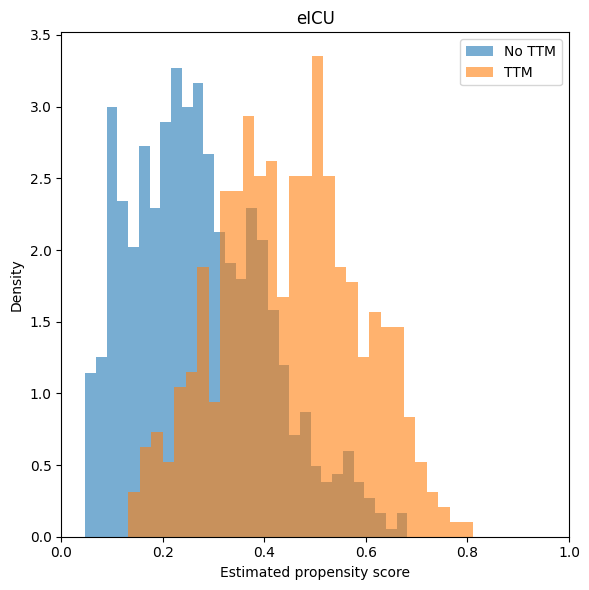

In [165]:
fig, axes = plt.subplots(1, 1, figsize=(6,6), sharey=True)

plot_propensity_overlap(ps_eicu, ax=axes, title="eICU")
# plot_propensity_overlap(ps_pmap, ax=axes[1], title="PMAP")
# plot_propensity_overlap(ps_mimic, ax=axes[2], title="MIMIC-IV")

plt.tight_layout()
plt.show()

In [121]:
def propensity_summary(df):
    """
    Summarize overlap / positivity diagnostics.
    """
    out = []

    for tval, group_name in [(0, "No TTM"), (1, "TTM")]:
        s = df.loc[df["T"] == tval, "propensity"]

        out.append({
            "group": group_name,
            "n": len(s),
            "min": s.min(),
            "p01": np.quantile(s, 0.01),
            "p05": np.quantile(s, 0.05),
            "median": s.median(),
            "p95": np.quantile(s, 0.95),
            "p99": np.quantile(s, 0.99),
            "max": s.max(),
            "prop_<0.05": np.mean(s < 0.05),
            "prop_>0.95": np.mean(s > 0.95),
            "prop_<0.10": np.mean(s < 0.10),
            "prop_>0.90": np.mean(s > 0.90),
        })

    return pd.DataFrame(out)

In [122]:
summary_eicu = propensity_summary(ps_eicu)
# summary_pmap = propensity_summary(ps_pmap)
# summary_mimic = propensity_summary(ps_mimic)

print(summary_eicu)
# print(summary_pmap)
# print(summary_mimic)

    group    n       min       p01       p05    median       p95       p99  \
0  No TTM  442  0.004802  0.005195  0.006924  0.021281  0.437623  0.568586   
1     TTM  118  0.206348  0.233313  0.360305  0.551012  0.722502  0.799945   

        max  prop_<0.05  prop_>0.95  prop_<0.10  prop_>0.90  
0  0.759063     0.61086         0.0    0.651584         0.0  
1  0.809598     0.00000         0.0    0.000000         0.0  


In [131]:
near_zero = ps_eicu[ps_eicu["propensity"] < 0.05].copy()
near_zero.head()
near_zero.shape

(391, 3)

In [132]:
ps_eicu.sort_values("propensity").head(20)

,dataset,T,propensity
507,eICU,0,0.004802
249,eICU,0,0.004843
38,eICU,0,0.004843
395,eICU,0,0.005136
268,eICU,0,0.005156
293,eICU,0,0.005250
37,eICU,0,0.005362
606,eICU,0,0.005365
583,eICU,0,0.005476
80,eICU,0,0.005511


In [139]:
ps_eicu.loc[ps_eicu["propensity"] < 0.05, "T"].value_counts(dropna=False)

T
0    270
Name: count, dtype: int64

In [145]:
index = ps_eicu.loc[ps_eicu["propensity"] < 0.05, "T"].index


In [151]:
X_train_no_group.iloc[index]

,age,bmi,diagnosis_initial rhythm: asystole,diagnosis_initial rhythm: pulseless electrical activity,diagnosis_initial rhythm: ventricular fibrillation,diagnosis_initial rhythm: ventricular tachycardia,diagnosis_ventricular fibrillation,diagnosis_ventricular tachycardia,gender,hypothermia_time,...,lab_first_troponin - I,lab_first_troponin - T,nurse_first_GCS Total,nurse_first_Heart Rate,nurse_first_Motor,nurse_first_Non-Invasive BP Diastolic,nurse_first_Non-Invasive BP Mean,nurse_first_Non-Invasive BP Systolic,nurse_first_O2 Saturation,nurse_first_QTc
942,69,36.185790,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.110,NaN,5.0,173.0,3.0,52.0,55.0,120.0,31.0,NaN
2321,41,33.461535,0.0,0.0,1.0,0.0,1.0,0.0,1,0.0,...,NaN,NaN,4.0,94.0,2.0,90.0,108.0,143.0,99.0,NaN
828,65,26.602217,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,...,0.628,NaN,9.0,74.0,5.0,75.0,82.0,109.0,95.0,NaN
1333,69,32.249937,0.0,0.0,1.0,0.0,0.0,0.0,0,0.0,...,NaN,NaN,8.0,108.0,2.0,139.0,106.0,203.0,NaN,NaN
2250,80,36.137056,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,NaN,0.92,NaN,37.0,NaN,37.0,44.0,81.0,82.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521,57,42.561583,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,NaN,NaN,NaN,0.0,4.0,103.0,67.0,198.0,98.0,NaN
424,88,25.780664,0.0,1.0,0.0,0.0,0.0,0.0,1,0.0,...,NaN,NaN,8.0,81.0,5.0,49.0,57.0,86.0,94.0,NaN
594,72,62.018730,1.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,NaN,NaN,10.0,80.0,5.0,80.0,99.0,193.0,100.0,NaN
1902,66,27.582122,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,NaN,0.30,8.0,105.0,4.0,98.0,134.0,205.0,NaN,NaN


In [123]:
def positivity_flag(df, low=0.05, high=0.95, frac_threshold=0.05):
    """
    Flag severe positivity issues if too many subjects lie near 0 or 1.
    """
    p = df["propensity"].values
    frac_extreme = np.mean((p < low) | (p > high))

    if frac_extreme >= frac_threshold:
        return {
            "severe_flag": True,
            "frac_extreme": frac_extreme,
            "message": f"Potential positivity concern: {frac_extreme:.1%} of scores are <{low} or >{high}."
        }
    else:
        return {
            "severe_flag": False,
            "frac_extreme": frac_extreme,
            "message": f"No major positivity concern by this rule: {frac_extreme:.1%} extreme scores."
        }

In [124]:
print("eICU:", positivity_flag(ps_eicu))
# print("PMAP:", positivity_flag(ps_pmap))
# print("MIMIC-IV:", positivity_flag(ps_mimic))

eICU: {'severe_flag': True, 'frac_extreme': np.float64(0.48214285714285715), 'message': 'Potential positivity concern: 48.2% of scores are <0.05 or >0.95.'}


In [125]:
def run_propensity_diagnostics(cf, T, X=None, W=None, dataset_name="dataset", bins=30):
    df = make_propensity_df(cf, T=T, X=X, W=W, dataset_name=dataset_name)
    summary = propensity_summary(df)
    flag = positivity_flag(df)

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_propensity_overlap(df, ax=ax, bins=bins, title=dataset_name)
    plt.tight_layout()

    return df, summary, flag, fig

In [15]:
T_all.shape

NameError: name 'T_all' is not defined

In [177]:
treat_prev = T_all.mean()

In [16]:
Y_all = np.concatenate([y_train, y_test])
baseline_risk = Y_all[T_all == 0].mean()

NameError: name 'T_all' is not defined

In [181]:
baseline_risk

np.float64(0.3687196110210697)

In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2


def simulate_dataset_hte(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    rng=None
):
    """
    Simulate binary outcomes with HTE present only in a latent subgroup.

    Parameters
    ----------
    n : int
        Sample size.
    treat_prev : float
        Treatment prevalence P(T=1).
    subgroup_prev : float
        Responsive subgroup prevalence P(G=1).
    baseline_risk : float
        Baseline outcome probability for untreated, non-subgroup patients.
    abs_treatment_effect : float
        Absolute treatment effect applied only within subgroup.
        Positive means benefit for a favorable outcome.
    rng : np.random.Generator or None

    Returns
    -------
    df : pd.DataFrame
        Simulated data with columns T, G, cate_score, Y
    """
    if rng is None:
        rng = np.random.default_rng()

    # Treatment assignment
    T = rng.binomial(1, treat_prev, size=n)

    # Latent subgroup that benefits
    G = rng.binomial(1, subgroup_prev, size=n)

    # True individual treatment effect:
    # only subgroup members benefit
    true_tau = abs_treatment_effect * G

    # Outcome probability
    # Here outcome is assumed favorable, so treatment increases probability
    p = baseline_risk + T * true_tau

    # keep probabilities in valid range
    p = np.clip(p, 1e-6, 1 - 1e-6)

    # Binary outcome
    Y = rng.binomial(1, p, size=n)

    # Oracle "CATE score"
    cate_score = true_tau

    return pd.DataFrame({
        "T": T,
        "G": G,
        "cate_score": cate_score,
        "Y": Y
    })

def lr_test_interaction(df):
    """
    Likelihood ratio test comparing:
      reduced: Y ~ T + cate_score
      full:    Y ~ T + cate_score + T:cate_score
    """
    X_reduced = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"]
    })

    X_full = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"],
        "interaction": df["T"] * df["cate_score"]
    })

    try:
        m0 = sm.Logit(df["Y"], X_reduced).fit(disp=False)
        m1 = sm.Logit(df["Y"], X_full).fit(disp=False)

        lr_stat = 2 * (m1.llf - m0.llf)
        df_diff = X_full.shape[1] - X_reduced.shape[1]
        pval = chi2.sf(lr_stat, df_diff)

        return {
            "lr_stat": lr_stat,
            "pval": pval,
            "converged": True
        }
    except Exception:
        return {
            "lr_stat": np.nan,
            "pval": np.nan,
            "converged": False
        }
def estimate_power_for_scenario(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    n_sims=1000,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)

    pvals = []
    n_fail = 0

    for _ in range(n_sims):
        df = simulate_dataset_hte(
            n=n,
            treat_prev=treat_prev,
            subgroup_prev=subgroup_prev,
            baseline_risk=baseline_risk,
            abs_treatment_effect=abs_treatment_effect,
            rng=rng
        )
        res = lr_test_interaction(df)
        if res["converged"] and np.isfinite(res["pval"]):
            pvals.append(res["pval"])
        else:
            n_fail += 1

    pvals = np.array(pvals)
    power = np.mean(pvals < alpha) if len(pvals) > 0 else np.nan

    return {
        "n": n,
        "treat_prev": treat_prev,
        "subgroup_prev": subgroup_prev,
        "baseline_risk": baseline_risk,
        "abs_treatment_effect": abs_treatment_effect,
        "n_sims": n_sims,
        "n_successful_fits": len(pvals),
        "n_failed_fits": n_fail,
        "power": power
    }
T_all = np.concatenate([T_train, T_test])
X_all = np.concatenate([myNewXTrain, myNewXTest])
Y_all = np.concatenate([y_train, y_test])
baseline_risk = Y_all[T_all == 0].mean()
dataset_specs = {
    "eICU": {"n": 2082, "treat_prev": 0.303, "baseline_risk": 1-baseline_risk},
}

results = []

for ds, spec in dataset_specs.items():
    for te in [0.1, 0.2, 0.3]:
        for subgroup_prev in [0.20, 0.30, 0.50]:
            out = estimate_power_for_scenario(
                n=spec["n"],
                treat_prev=spec["treat_prev"],
                subgroup_prev=subgroup_prev,
                baseline_risk=spec["baseline_risk"],
                abs_treatment_effect=te,
                n_sims=2000,
                alpha=0.05,
                seed=42
            )
            out["dataset"] = ds
            results.append(out)

power_table = pd.DataFrame(results)
power_table = power_table[[
    "dataset", "n", "treat_prev", "subgroup_prev",
    "baseline_risk", "abs_treatment_effect",
    "n_sims", "power", "n_failed_fits"
]]
import pandas as pd

power_table_paper = power_table.copy()

# convert to paper-friendly values
power_table_paper["subgroup_prev"] = (power_table_paper["subgroup_prev"] * 100).astype(int)

# rename columns
power_table_paper = power_table_paper.rename(columns={
    "dataset": "Dataset",
    "n": "N",
    "treat_prev": "TTM prevalence",
    "subgroup_prev": "Responsive subgroup (%)",
    "baseline_risk": "Baseline risk",
    "abs_treatment_effect": "Assumed absolute treatment effect",
    "n_sims": "Simulations",
    "power": "Power",
    "n_failed_fits": "Failed fits"
})

# round numeric columns
power_table_paper["TTM prevalence"] = power_table_paper["TTM prevalence"].round(3)
power_table_paper["Baseline risk"] = power_table_paper["Baseline risk"].round(3)
power_table_paper["Assumed absolute treatment effect"] = power_table_paper["Assumed absolute treatment effect"].round(2)
power_table_paper["Power"] = power_table_paper["Power"].round(3)

# optional: format N and Simulations with commas
power_table_paper["N"] = power_table_paper["N"].map(lambda x: f"{x:,}")
power_table_paper["Simulations"] = power_table_paper["Simulations"].map(lambda x: f"{x:,}")
power_table_paper.to_csv('power.csv')
power_table_paper

,Dataset,N,TTM prevalence,Responsive subgroup (%),Baseline risk,Assumed absolute treatment effect,Simulations,Power,Failed fits
0,eICU,"2,082",0.303,20,0.484,0.1,"2,000",0.402,0
1,eICU,"2,082",0.303,30,0.484,0.1,"2,000",0.511,0
2,eICU,"2,082",0.303,50,0.484,0.1,"2,000",0.582,0
3,eICU,"2,082",0.303,20,0.484,0.2,"2,000",0.934,0
4,eICU,"2,082",0.303,30,0.484,0.2,"2,000",0.974,0
5,eICU,"2,082",0.303,50,0.484,0.2,"2,000",0.990,0
6,eICU,"2,082",0.303,20,0.484,0.3,"2,000",1.000,0
7,eICU,"2,082",0.303,30,0.484,0.3,"2,000",1.000,0
8,eICU,"2,082",0.303,50,0.484,0.3,"2,000",1.000,0


,Dataset,N,TTM prevalence,Responsive subgroup (%),Baseline risk,Assumed absolute treatment effect,Simulations,Power,Failed fits
0,eICU,"1,842",0.33,20,0.631,0.1,"2,000",0.411,0
1,eICU,"1,842",0.33,30,0.631,0.1,"2,000",0.516,0
2,eICU,"1,842",0.33,50,0.631,0.1,"2,000",0.580,0
3,eICU,"1,842",0.33,20,0.631,0.2,"2,000",0.968,0
4,eICU,"1,842",0.33,30,0.631,0.2,"2,000",0.986,0
5,eICU,"1,842",0.33,50,0.631,0.2,"2,000",0.996,0
6,eICU,"1,842",0.33,20,0.631,0.3,"2,000",1.000,0
7,eICU,"1,842",0.33,30,0.631,0.3,"2,000",1.000,0
8,eICU,"1,842",0.33,50,0.631,0.3,"2,000",1.000,0


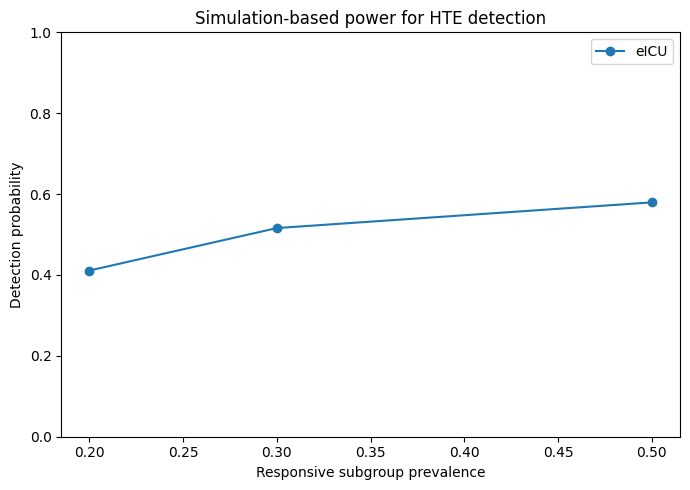

In [189]:
import matplotlib.pyplot as plt

def plot_power_curves(power_table):
    fig, ax = plt.subplots(figsize=(7, 5))

    for ds, subdf in power_table.groupby("dataset"):
        subdf = subdf.sort_values("subgroup_prev")
        ax.plot(
            subdf["subgroup_prev"],
            subdf["power"],
            marker="o",
            label=ds
        )

    ax.set_xlabel("Responsive subgroup prevalence")
    ax.set_ylabel("Detection probability")
    ax.set_title("Simulation-based power for HTE detection")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_power_curves(power_table)

In [196]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
def missingness_table(df, treatment_col, threshold=30.0, exclude_cols=None, use_fisher_if_small=True):
    """
    Create a missingness summary table for one dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Pre-imputation dataframe.
    treatment_col : str
        Name of binary treatment column (0/1).
    threshold : float
        Percent missing threshold to flag, default 30.
    exclude_cols : list or None
        Columns to exclude from the missingness table.
    use_fisher_if_small : bool
        Use Fisher's exact test when expected cell counts are small.

    Returns
    -------
    pd.DataFrame
    """
    if exclude_cols is None:
        exclude_cols = []

    cols = [c for c in df.columns if c not in exclude_cols and c != treatment_col]

    rows = []

    treat = df[treatment_col]

    for col in cols:
        miss = df[col].isna().astype(int)

        n_total = len(df)
        n_missing = miss.sum()
        pct_missing = 100 * n_missing / n_total

        miss_ttm = miss[treat == 1]
        miss_nottm = miss[treat == 0]

        n_ttm = (treat == 1).sum()
        n_nottm = (treat == 0).sum()

        pct_missing_ttm = 100 * miss_ttm.mean() if n_ttm > 0 else np.nan
        pct_missing_nottm = 100 * miss_nottm.mean() if n_nottm > 0 else np.nan

        # contingency table:
        # rows = treatment group
        # cols = missing / not missing
        table = np.array([
            [miss_nottm.sum(), (treat == 0).sum() - miss_nottm.sum()],
            [miss_ttm.sum(), (treat == 1).sum() - miss_ttm.sum()]
        ])

        # default p-value
        pval = np.nan
        test_used = None

        try:
            chi2, p_chi, dof, expected = chi2_contingency(table, correction=False)

            if use_fisher_if_small and (expected < 5).any():
                _, pval = fisher_exact(table)
                test_used = "Fisher"
            else:
                pval = p_chi
                test_used = "Chi-square"
        except Exception:
            pval = np.nan
            test_used = "Failed"

        rows.append({
            "variable": col,
            "n_missing": int(n_missing),
            "pct_missing": pct_missing,
            "pct_missing_no_ttm": pct_missing_nottm,
            "pct_missing_ttm": pct_missing_ttm,
            "abs_diff_pct": abs(pct_missing_ttm - pct_missing_nottm),
            "p_value": pval,
            "test": test_used,
            "flag_gt_30pct": pct_missing > threshold
        })

    out = pd.DataFrame(rows).sort_values(
        ["flag_gt_30pct", "pct_missing"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out
miss_eicu = missingness_table(
    df=X_train_no_group,
    treatment_col="Hypothermia",
    exclude_cols=["patient_id"]
)
def missingness_summary_stats(miss_df):
    return {
        "n_variables": len(miss_df),
        "n_gt_30pct": int(miss_df["flag_gt_30pct"].sum()),
        "max_pct_missing": miss_df["pct_missing"].max(),
        "median_pct_missing": miss_df["pct_missing"].median(),
        "n_p_lt_005": int((miss_df["p_value"] < 0.05).sum())
    }

KeyError: 'Hypothermia'

In [194]:
print("eICU:", missingness_summary_stats(miss_eicu))

eICU: {'n_variables': 1790, 'n_gt_30pct': 725, 'max_pct_missing': np.float64(100.0), 'median_pct_missing': np.float64(10.586319218241043), 'n_p_lt_005': 1192}


    group     n       min       p01       p05    median       p95       p99  \
0  No TTM  1234  0.036023  0.056122  0.087597  0.266936  0.540123  0.635169   
1     TTM   608  0.091205  0.131809  0.192051  0.435122  0.666467  0.721982   

        max  prop_<0.05  prop_>0.95  prop_<0.10  prop_>0.90  
0  0.760205    0.004052         0.0    0.084279         0.0  
1  0.810492    0.000000         0.0    0.003289         0.0  
{'severe_flag': False, 'frac_extreme': np.float64(0.0027144408251900108), 'message': 'No major positivity concern by this rule: 0.3% extreme scores.'}


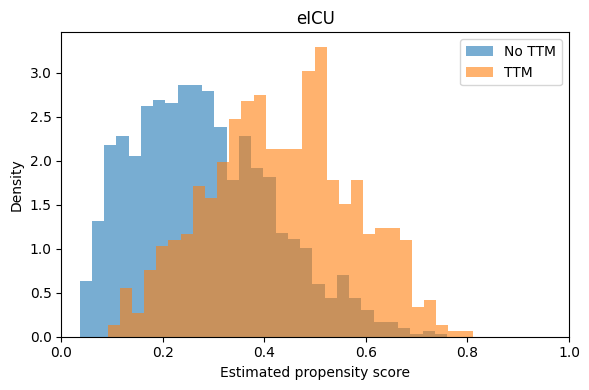

In [175]:
T_all = np.concatenate([T_train, T_test])
X_all = np.concatenate([myNewXTrain, myNewXTest])
ps_eicu, sum_eicu, flag_eicu, fig_eicu = run_propensity_diagnostics(
    causal_forest, T=T_all, X=X_all, W=None, dataset_name="eICU"
)
print(sum_eicu)
print(flag_eicu)

In [127]:
importances.shape

NameError: name 'importances' is not defined

In [128]:
len(feature_names)

NameError: name 'feature_names' is not defined

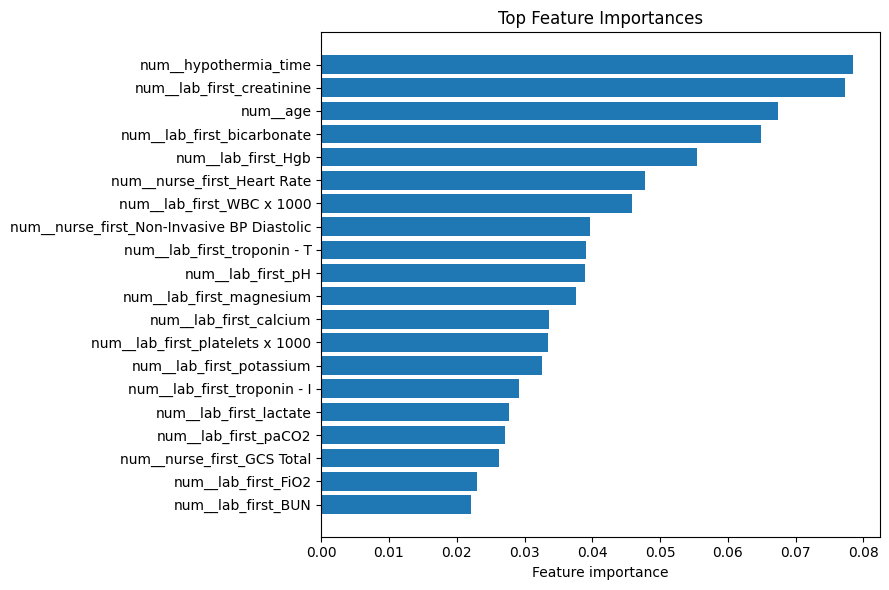

In [129]:
import numpy as np
import matplotlib.pyplot as plt

# feature importances from your model
importances = causal_forest.feature_importances_

feature_names = myNewXTrain.columns.to_list()

# safety check
assert len(importances) == len(feature_names), "Mismatch between importances and features"

# sort features by importance
idx = np.argsort(importances)[::-1]

# plot (top-k recommended)
k = 20
top_idx = idx[:k]

plt.figure(figsize=(9, 6))
plt.barh(
    [feature_names[i] for i in top_idx],
    importances[top_idx]
)
plt.xlabel("Feature importance")
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [118]:
causal_forest.summary()

Population summary of CATE predictions on Training Data


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  88 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.5s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.1s finished


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate               
================================================================
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
    -0.105       0.092 -1.134  0.257        -0.286         0.076
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.058          -0.223             0.0
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.109         -0.327          0.105
        Doubly Robust ATE on Training Data Results       
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATE         -0.171  0.097 -1.766  0.077   -0.362    0.019
     Doubly Robust ATT(T=0) on Training Data Results     
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATT          -0.16  0.049 -3.288  0.001   -0.255   -0.065
     Doubly Robust ATT(T=1) on Training Data Results     
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATT         -0.194  0.269 -0.721  0.471   -0.721    0.333
---------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

In [119]:
myNewFeaturesDf = pd.DataFrame(np.array([causal_forest.feature_importances_]), columns = myPipeline.get_feature_names_out())

In [120]:
myColumns = myNewFeaturesDf.loc[:, myNewFeaturesDf.sum().nlargest(15).index].columns
myColumns

Index(['num__nurse_first_GCS Total', 'num__lab_first_troponin - I',
       'num__lab_first_pH', 'num__bmi', 'num__lab_first_Hgb',
       'num__lab_first_WBC x 1000', 'num__lab_first_BUN',
       'num__lab_first_lactate', 'num__lab_first_potassium',
       'num__lab_first_Respiratory Rate', 'remainder__nurse_first_Motor_4.0',
       'num__lab_first_creatinine',
       'num__nurse_first_Non-Invasive BP Diastolic', 'num__lab_first_paO2',
       'num__lab_first_calcium'],
      dtype='object')

In [121]:
myMainColumns = myColumns.str.split('__').str[-1]

In [122]:
myMainColumns

Index(['nurse_first_GCS Total', 'lab_first_troponin - I', 'lab_first_pH',
       'bmi', 'lab_first_Hgb', 'lab_first_WBC x 1000', 'lab_first_BUN',
       'lab_first_lactate', 'lab_first_potassium',
       'lab_first_Respiratory Rate', 'nurse_first_Motor_4.0',
       'lab_first_creatinine', 'nurse_first_Non-Invasive BP Diastolic',
       'lab_first_paO2', 'lab_first_calcium'],
      dtype='object')

In [34]:
# myNewXTest = myPipeline.transform(X_test_no_group)
causal_forest.score(y_test, T_test, myNewXTest)

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.1972503817988958

In [39]:
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [43]:
myData = pd.concat([myNewXTrain.reset_index(), myNewDf.reset_index(), T_train.reset_index(), y_train_df.reset_index()], axis=1)
myData['TreatmentColumn'] = myData[myTreatment]
myData.columns = myData.columns.str.replace(' ', '_')
myData.columns = myData.columns.str.replace('-', '_')
myData.columns = myData.columns.str.replace('(', '_')
myData.columns = myData.columns.str.replace(')', '_')
myColumns2 = myColumns.str.replace(' ', '_')
myColumns2 = myColumns2.str.replace('-', '_')
myColumns2 = myColumns2.str.replace('(', '_')
myColumns2 = myColumns2.str.replace(')', '_')
string = ''
for column in myColumns2:
    string += f'{column}* TreatmentColumn + '
myInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn' ,
    data=myData
).fit()
myInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.614508
         Iterations 6


The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1694
Method:                           MLE   Df Model:                           31
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.09467
Time:                        15:21:55   Log-Likelihood:                -1060.6
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 1.045e-30
============================================================================================================================
                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                    0.4647      0.116      4.010      0.000       0.238       0.692
num__lab_mean_troponin___T                                  -0.2460      0.195     -1.263      0.207      -0.628       0.136
TreatmentColumn                                              0.2248      0.260      0.866      0.387      -0.284       0.734
num__lab_mean_troponin___T:TreatmentColumn                   0.2423      0.250      0.969      0.333      -0.248       0.733
num__lab_min_ALT__SGPT_                                      0.1835      0.088      2.090      0.037       0.011       0.356
num__lab_min_ALT__SGPT_:TreatmentColumn                      0.1975      0.235      0.840      0.401      -0.263       0.658
num__nurse_max_Respiratory_Rate                              0.1729      0.086      2.017      0.044       0.005       0.341
num__nurse_max_Respiratory_Rate:TreatmentColumn             -0.2338      0.139     -1.681      0.093      -0.506       0.039
num__lab_min_Total_CO2                                      -0.0660      0.111     -0.596      0.551      -0.283       0.151
num__lab_min_Total_CO2:TreatmentColumn                      -0.0780      0.210     -0.371      0.711      -0.490       0.334
num__lab_max_free_T4                                        -0.1516      0.213     -0.711      0.477      -0.570       0.266
num__lab_max_free_T4:TreatmentColumn                         0.0802      0.572      0.140      0.888      -1.040       1.201
num__nurse_last_Non_Invasive_BP_Systolic                    -0.1220      0.064     -1.913      0.056      -0.247       0.003
num__nurse_last_Non_Invasive_BP_Systolic:TreatmentColumn     0.2356      0.142      1.660      0.097      -0.043       0.514
num__nurse_mean_CI                                           0.4910      0.224      2.197      0.028       0.053       0.929
num__nurse_mean_CI:TreatmentColumn                          -0.1960      0.475     -0.413      0.680      -1.127       0.735
num__nurse_max_PA_Systolic                                   0.5500      0.350      1.570      0.116      -0.136       1.236
num__nurse_max_PA_Systolic:TreatmentColumn                   0.7307      0.823      0.887      0.375      -0.883       2.344
num__lab_max__monos                                         -0.1819      0.073     -2.484      0.013      -0.325      -0.038
num__lab_max__monos:TreatmentColumn                         -0.0089      0.162     -0.055      0.956      -0.326       0.309
num__FirstGCS                                               -0.5423      0.066     -8.273      0.000      -0.671      -0.414
num__FirstGCS:TreatmentColumn                               -0.0428      0.166     -0.258      0.797      -0.368       0.283
num__lab_last_paCO2                                          0.1708      0.072      2.381      0.017       0.030    

In [44]:
myData = pd.concat([myNewXTrain.reset_index(), myNewDf.reset_index(), T_train.reset_index(), y_train_df.reset_index()], axis=1)
myData['TreatmentColumn'] = myData[myTreatment]
myData.columns = myData.columns.str.replace(' ', '_')
myData.columns = myData.columns.str.replace('-', '_')
myData.columns = myData.columns.str.replace('(', '_')
myData.columns = myData.columns.str.replace(')', '_')
myColumns2 = myColumns.str.replace(' ', '_')
myColumns2 = myColumns2.str.replace('-', '_')
myColumns2 = myColumns2.str.replace('(', '_')
myColumns2 = myColumns2.str.replace(')', '_')
string = ''
for column in myColumns2:
    string += f'{column} + '
myNoInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn' ,
    data=myData
).fit()
myNoInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.617501
         Iterations 6


The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1709
Method:                           MLE   Df Model:                           16
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.09026
Time:                        15:22:25   Log-Likelihood:                -1065.8
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 3.729e-36
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.5054      0.105      4.813      0.000       0.300       0.711
num__lab_mean_troponin___T                  -0.1030      0.116     -0.890      0.373      -0.330       0.124
num__lab_min_ALT__SGPT_                      0.2161      0.083      2.613      0.009       0.054       0.378
num__nurse_max_Respiratory_Rate              0.1013      0.065      1.554      0.120      -0.026       0.229
num__lab_min_Total_CO2                      -0.0962      0.095     -1.013      0.311      -0.282       0.090
num__lab_max_free_T4                        -0.1371      0.195     -0.704      0.481      -0.519       0.244
num__nurse_last_Non_Invasive_BP_Systolic    -0.0748      0.056     -1.328      0.184      -0.185       0.036
num__nurse_mean_CI                           0.4398      0.196      2.247      0.025       0.056       0.823
num__nurse_max_PA_Systolic                   0.6403      0.313      2.048      0.041       0.027       1.253
num__lab_max__monos                         -0.1807      0.065     -2.783      0.005      -0.308      -0.053
num__FirstGCS                               -0.5455      0.060     -9.156      0.000      -0.662      -0.429
num__lab_last_paCO2                          0.1662      0.062      2.681      0.007       0.045       0.288
num__lab_mean_Ferritin                       0.3139      0.219      1.433      0.152      -0.115       0.743
num__lab_max_Methemoglobin                  -0.2188      0.104     -2.108      0.035      -0.422      -0.015
num__nurse_min_Invasive_BP_Diastolic        -0.2338      0.082     -2.862      0.004      -0.394      -0.074
num__lab_max_ionized_calcium                -0.0278      0.087     -0.322      0.748      -0.197       0.142
TreatmentColumn                              0.0308      0.126      0.244      0.807      -0.217       0.279
============================================================================================================
"""

In [45]:
myInteractionModel.pvalues[myInteractionModel.pvalues < 0.05].index

Index(['Intercept', 'num__lab_min_ALT__SGPT_',
       'num__nurse_max_Respiratory_Rate', 'num__nurse_mean_CI',
       'num__lab_max__monos', 'num__FirstGCS', 'num__lab_last_paCO2',
       'num__nurse_min_Invasive_BP_Diastolic'],
      dtype='object')

In [47]:
myColumns3 = list(myInteractionModel.pvalues[myInteractionModel.pvalues < 0.05].index)

In [48]:
string = ''
for column in myColumns3:
    if ':' in column:
        column = column.split(':')[0]
    if column != 'Intercept':
        string += f'{column}* TreatmentColumn + '
myInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn',
    data=myData
).fit()
myInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.620649
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1710
Method:                           MLE   Df Model:                           15
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.08562
Time:                        15:23:06   Log-Likelihood:                -1071.2
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 1.586e-34
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept                                                0.4677      0.065      7.175      0.000       0.340       0.595
num__lab_min_ALT__SGPT_                                  0.1758      0.083      2.112      0.035       0.013       0.339
TreatmentColumn                                         -0.0477      0.145     -0.328      0.743      -0.333       0.237
num__lab_min_ALT__SGPT_:TreatmentColumn                  0.1954      0.227      0.860      0.390      -0.250       0.641
num__nurse_max_Respiratory_Rate                          0.2082      0.082      2.543      0.011       0.048       0.369
num__nurse_max_Respiratory_Rate:TreatmentColumn         -0.2103      0.131     -1.601      0.109      -0.468       0.047
num__nurse_mean_CI                                       0.4711      0.219      2.150      0.032       0.042       0.901
num__nurse_mean_CI:TreatmentColumn                      -0.1959      0.465     -0.421      0.674      -1.107       0.715
num__lab_max__monos                                     -0.1858      0.072     -2.581      0.010      -0.327      -0.045
num__lab_max__monos:TreatmentColumn                      0.0221      0.158      0.140      0.889      -0.288       0.332
num__FirstGCS                                           -0.5350      0.061     -8.757      0.000      -0.655      -0.415
num__FirstGCS:TreatmentColumn                           -0.0041      0.159     -0.026      0.979      -0.317       0.308
num__lab_last_paCO2                                      0.1642      0.068      2.432      0.015       0.032       0.297
num__lab_last_paCO2:TreatmentColumn                     -0.0263      0.140     -0.188      0.851      -0.300       0.248
num__nurse_min_Invasive_BP_Diastolic                    -0.3285      0.098     -3.361      0.001      -0.520      -0.137
num__nurse_min_Invasive_BP_Diastolic:TreatmentColumn     0.2174      0.178      1.222      0.222      -0.131       0.566
========================================================================================================================
"""

In [49]:
string = ''
for column in myColumns3:
    if ':' in column:
        column = column.split(':')[0]
    if column != 'Intercept':
        string += f'{column} + '
myNoInteractionModel = smf.logit(
    f'{myPredicted} ~ ' + string + 'TreatmentColumn',
    data=myData
).fit()
myNoInteractionModel.summary()

Optimization terminated successfully.
         Current function value: 0.622210
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1717
Method:                           MLE   Df Model:                            8
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                 0.08332
Time:                        15:23:12   Log-Likelihood:                -1073.9
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                 6.434e-38
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                0.4478      0.063      7.078      0.000       0.324       0.572
num__lab_min_ALT__SGPT_                  0.2086      0.079      2.634      0.008       0.053       0.364
num__nurse_max_Respiratory_Rate          0.1396      0.062      2.236      0.025       0.017       0.262
num__nurse_mean_CI                       0.4164      0.192      2.167      0.030       0.040       0.793
num__lab_max__monos                     -0.1830      0.064     -2.860      0.004      -0.308      -0.058
num__FirstGCS                           -0.5381      0.056     -9.570      0.000      -0.648      -0.428
num__lab_last_paCO2                      0.1572      0.059      2.678      0.007       0.042       0.272
num__nurse_min_Invasive_BP_Diastolic    -0.2693      0.081     -3.343      0.001      -0.427      -0.111
TreatmentColumn                          0.0083      0.125      0.066      0.947      -0.237       0.253
========================================================================================================
"""

In [50]:
llr = -2*(myNoInteractionModel.llf - myInteractionModel.llf)
df_diff = myInteractionModel.df_model - myNoInteractionModel.df_model
p_value = chi2.sf(llr, df_diff)

print(f'Likelihood ratio of test results:')
print(f'Chi square statistic: {llr}')
print(f'p-value: {p_value}')
print(f'Degress of freedom: {df_diff}')

Likelihood ratio of test results:
Chi square statistic: 5.3870208569242095
p-value: 0.6128439227802598
Degress of freedom: 7.0


In [60]:
causal_forest.get_model_t().predict(myNewXTrain)

AttributeError: 'CausalForestDML' object has no attribute 'get_model_t'

Optimization terminated successfully.
         Current function value: 0.634312
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.634215
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.2499140261845696
p-value: 0.6171356207576066
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1289
Model:                          Logit   Df Residuals:                     1286
Method:                           MLE   Df Model:                            2
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                0.007871
Time:                        11:51:29   Log-Likelihood:                -817.63
converged:                       True   LL-Null:                       -824.11
Covariance Type:            nonrobust   LLR p-value:                  0.001524
                      

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


np.float64(0.6171356207576066)

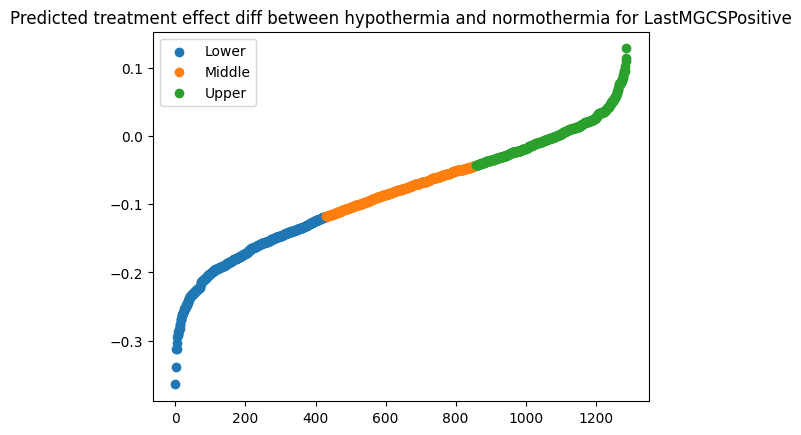

In [171]:
# myNewXTrain = pd.DataFrame(myPipeline.transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTrain)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
# myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)

X_train_new = X_train_no_group.copy().reset_index()
X_train_new[myTreatment] = T_train.reset_index()[myTreatment]
y_train_df = pd.DataFrame()
y_train_df[myPredicted] = y_train.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_train_new, y_train_df, myNewDf, myPredicted, myTreatment, False)

In [103]:
pd.DataFrame((cate_upper < 0) & (cate_lower < 0)).sum()

0    0
dtype: int64

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.0s finished


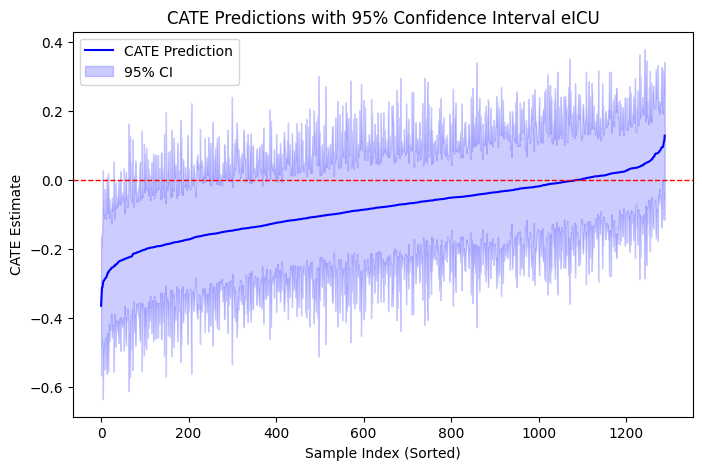

In [173]:
import matplotlib.pyplot as plt
import numpy as np

# Compute CATE prediction intervals
CATE_pred = causal_forest.effect(myNewXTrain)

cate_lower, cate_upper = causal_forest.effect_interval(myNewXTrain, alpha=0.05)

# Ensure arrays are 1D NumPy arrays
CATE_pred = np.array(CATE_pred).flatten()
cate_lower = np.array(cate_lower).flatten()
cate_upper = np.array(cate_upper).flatten()

# Sort values for a cleaner plot
sorted_idx = np.argsort(CATE_pred)
cate_pred_sorted = CATE_pred[sorted_idx]
cate_lower_sorted = cate_lower[sorted_idx]
cate_upper_sorted = cate_upper[sorted_idx]

# Create x-axis index
x = np.arange(len(cate_pred_sorted))

# Plot CATE predictions
plt.figure(figsize=(8, 5))
plt.plot(x, cate_pred_sorted, label='CATE Prediction', color='blue')

# Fill confidence interval
plt.fill_between(x, cate_lower_sorted, cate_upper_sorted, 
                 color='blue', alpha=0.2, label='95% CI')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
# Labels and title
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("CATE Estimate")
plt.title("CATE Predictions with 95% Confidence Interval eICU")
plt.legend()
plt.show()


Optimization terminated successfully.
         Current function value: 0.635044
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.634546
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.5507662807086717
p-value: 0.4580047612111052
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  553
Model:                          Logit   Df Residuals:                      550
Method:                           MLE   Df Model:                            2
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                0.007440
Time:                        11:51:14   Log-Likelihood:                -351.18
converged:                       True   LL-Null:                       -353.81
Covariance Type:            nonrobust   LLR p-value:                   0.07190
                      

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


np.float64(0.4580047612111052)

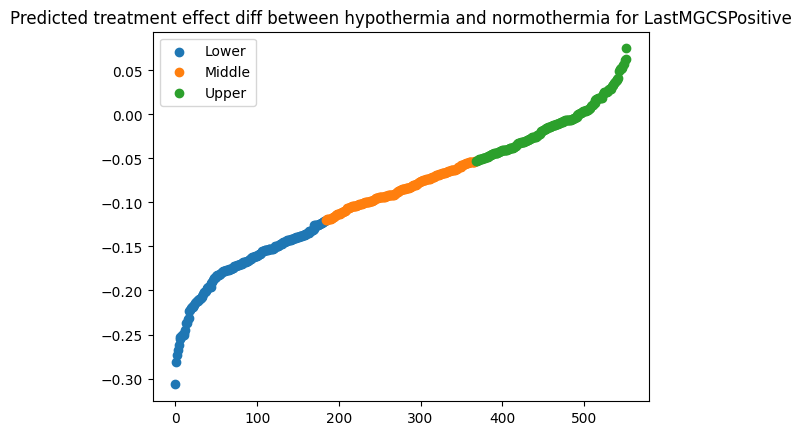

In [170]:
# myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
# myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)


X_test_new = X_test_no_group.copy().reset_index()
X_test_new[myTreatment] = T_test.reset_index()[myTreatment]
y_test_df = pd.DataFrame()
y_test_df[myPredicted] = y_test.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_test_new, y_test_df, myNewDf, myPredicted, myTreatment, False)

In [100]:
myNewDf[myPredicted]= y_train.reset_index()[myPredicted]
myNewDf[myTreatment]= T_train.reset_index()[myTreatment]

In [101]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

,predicted_effect_group,both_hypothermia,LastMGCSPositive,index,percent
0,False,0,120,289,0.415225
1,False,1,26,107,0.242991
2,True,0,123,257,0.478599
3,True,1,27,125,0.216000


In [102]:
# test_stat = causal_forest.test_stat(X_test)

In [236]:
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTest)

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-3)  # Adjust threshold as needed
myNewXTest = selector.fit_transform(myNewXTest)

X_test_const = sm.add_constant(myNewXTest)

# Fit logistic regression (binary effect variable)
logit_model = sm.OLS(CATE_pred, X_test_const).fit()
logit_model.summary()

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     56.40
Date:                Tue, 25 Feb 2025   Prob (F-statistic):          5.42e-135
Time:                        08:52:50   Log-Likelihood:                 1062.3
No. Observations:                 778   AIC:                            -2083.
Df Residuals:                     757   BIC:                            -1985.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0639      0.004    -16.589      0.000      -0.071      -0.056
x1            -0.0699      0.006    -11.883      0.000      -0.081      -0.058
x2             0.0481      0.010      4.635      0.000       0.028       0.068
x3            -0.0478      0.006     -7.363      0.000      -0.061      -0.035
x4             0.0123      0.008      1.556      0.120      -0.003       0.028
x5            -0.0054      0.006     -0.872      0.383      -0.017       0.007
x6             0.0143      0.007      1.973      0.049    7.33e-05       0.028
x7            -0.0150      0.010     -1.439      0.151      -0.036       0.005
x8            -0.0041      0.003     -1.240      0.216      -0.011       0.002
x9            -0.0143      0.013     -1.128      0.260      -0.039       0.011
x10            0.0067      0.003      2.605      0.009       0.002       0.012
x11           -0.0019      0.003     -0.741      0.459      -0.007       0.003
x12           -0.0037      0.008     -0.462      0.644      -0.019       0.012
x13            0.0002      0.004      0.037      0.970      -0.009       0.009
x14           -0.0301      0.011     -2.798      0.005      -0.051      -0.009
x15            0.0326      0.005      6.887      0.000       0.023       0.042
x16            0.0052      0.003      2.005      0.045       0.000       0.010
x17           -0.0502      0.013     -3.885      0.000      -0.076      -0.025
x18           -0.0099      0.003     -3.117      0.002      -0.016      -0.004
x19            0.0035      0.004      0.913      0.362      -0.004       0.011
x20           -0.0147      0.006     -2.627      0.009      -0.026      -0.004
==============================================================================
Omnibus:                        5.221   Durbin-Watson:                   2.109
Prob(Omnibus):                  0.074   Jarque-Bera (JB):                5.968
Skew:                          -0.096   Prob(JB):                       0.0506
Kurtosis:                       3.384   Cond. No.                         10.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [89]:
myNewXTest.shape

(778, 1942)

In [82]:
CATE_pred.

(778, 1)